In [3]:
import sys
print(sys.executable)

c:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe


In [4]:
import plotly

print(plotly.__version__)

6.7.0


In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Downloads\passenger_survey_balanced.csv")
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57514 entries, 0 to 57513
Columns: 145 entries, process to connection_wait_time_is_applicable
dtypes: float64(62), int64(60), object(23)
memory usage: 63.6+ MB


,disembarkation_method_rating,curbside_dropoff_ease,transport_options_to_airport,checkin_process,checkin_queue_wait_time,checkin_queue_organization,self_service_kiosk_quantity,checkin_counter_quantity,staff_courtesy,checkin_service_time,...,restrooms_is_applicable,restroom_quantity_is_applicable,restroom_cleanliness_is_applicable,restroom_maintenance_is_applicable,baggage_claim_process_is_applicable,baggage_carousel_identification_ease_is_applicable,baggage_claim_time_is_applicable,baggage_integrity_is_applicable,arrival_lead_time_is_applicable,connection_wait_time_is_applicable
count,330.000000,20958.000000,16829.000000,8489.000000,1843.000000,1822.000000,340.000000,1582.000000,1587.000000,1587.000000,...,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000
mean,3.739394,4.131215,3.807832,4.075745,2.670646,2.875412,3.220588,2.665613,3.615627,3.293636,...,0.578694,0.131133,0.131133,0.131133,0.421306,0.085910,0.085910,0.085910,0.387871,0.190823
std,1.171583,0.953496,1.055072,1.122362,1.305023,1.276820,1.142445,1.239787,1.196762,1.251271,...,0.493773,0.337549,0.337549,0.337549,0.493773,0.280233,0.280233,0.280233,0.487269,0.392953
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,3.000000,4.000000,1.500000,2.000000,2.000000,2.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

airline_service                    57459
customs_staff_service              57288
customs_queue_organization         57281
customs_queue_wait_time            57279
terminal_accessibility             57237
disembarkation_method_rating       57184
self_service_kiosk_quantity        57174
reserved_seat_availability         57152
parking_value_for_money            57029
parking_facility_quality           57020
parking_terminal_access_ease       57019
parking_space_availability_ease    57019
immigration_staff_service          56864
immigration_queue_organization     56857
service_window_quantity            56851
immigration_queue_wait_time        56847
parking                            56226
checkin_counter_quantity           55932
staff_courtesy                     55927
checkin_service_time               55927
dtype: int64

In [7]:
df_q1 = df[[
    "process",
    "flight_type",
    "ticket_purchased_by",
    "ticket_purchase_channel",
    "transport_to_airport",
    "has_disability",
    "uses_assistive_device",
    "requested_special_assistance",
    "trip_purpose",
    "gender",
    "age_group",
    "education",
    "household_income",
    "nationality"
]].copy()

In [8]:
df_q1.head()
df_q1.isnull().sum()

process                             0
flight_type                         0
ticket_purchased_by                 0
ticket_purchase_channel         16140
transport_to_airport                1
has_disability                      0
uses_assistive_device            1701
requested_special_assistance     1027
trip_purpose                    24231
gender                              0
age_group                       24231
education                       24231
household_income                24231
nationality                         0
dtype: int64

In [9]:
df_q1 = df[[
    "process",
    "flight_type",
    "ticket_purchased_by",
    "ticket_purchase_channel",
    "transport_to_airport",
    "has_disability",
    "uses_assistive_device",
    "requested_special_assistance",
    "gender",
    "nationality"
]].copy()

In [10]:
df_q1["process"].value_counts()

process
Boarding          33283
Disembarkation    24231
Name: count, dtype: int64

In [11]:
df.groupby("process")["gender"].value_counts()


process         gender
Boarding        Male      17338
                Female    15945
Disembarkation  Female    12684
                Male      11547
Name: count, dtype: int64

What does this tell us?
The distribution is fairly balanced.
Boarding passengers are slightly more male.
Disembarkation passengers are slightly more female.
No extreme imbalance exists.

Business Insight
Gender does not appear to be a major distinguishing characteristic of the passenger base.

Therefore, broad service improvements are likely to impact both genders similarly, rather than requiring heavily gender-specific initiatives.

In [12]:
df.groupby("process")["flight_type"].value_counts()

process         flight_type  
Boarding        Domestic         30212
                International     3071
Disembarkation  Domestic         21796
                International     2435
Name: count, dtype: int64

What does this tell us?
This is much more interesting.
Let's total them:
Domestic = 52,008
International = 5,506
Approximately 90% domestic and 10% international.

Business Insight
The airport's passenger base is overwhelmingly domestic.
This means:
Most customer satisfaction improvements will affect domestic travelers.
Domestic passenger experience should be the primary operational focus.
International passengers are a smaller segment, but may still require specialized services such as immigration, customs, and language support.

In [17]:
age_counts = df["age_group"].value_counts(dropna=False)
age_counts

age_group
NaN               24231
26 to 35 years    11249
36 to 45 years     9808
46 to 55 years     5093
18 to 25 years     4237
56 to 65 years     2175
Over 65 years       721
Name: count, dtype: int64

The passenger base is concentrated in working-age adults, especially:

26–35 years
36–45 years

Together they account for the majority of passengers with known age information.

In [19]:
trip_purpose = df["trip_purpose"].value_counts(dropna=False)
trip_purpose

trip_purpose
NaN                       24231
Leisure                   15680
Business                  12037
Family                     2017
Other                      1298
Leisure and business        726
Study/conference            717
Health                      338
Relocation/return home      203
Sports                       95
Funeral                      72
Legal/embassy                66
Unknown/no answer            21
Religious/mission             8
Exam/selection process        2
Shopping                      2
Wedding                       1
Name: count, dtype: int64

The passenger base appears to be dominated by:

Leisure travelers
Business travelers

Together they represent the overwhelming majority of known travel purposes.

That means management should pay particular attention to:

convenience and efficiency for business travelers
comfort and overall experience for leisure travelers

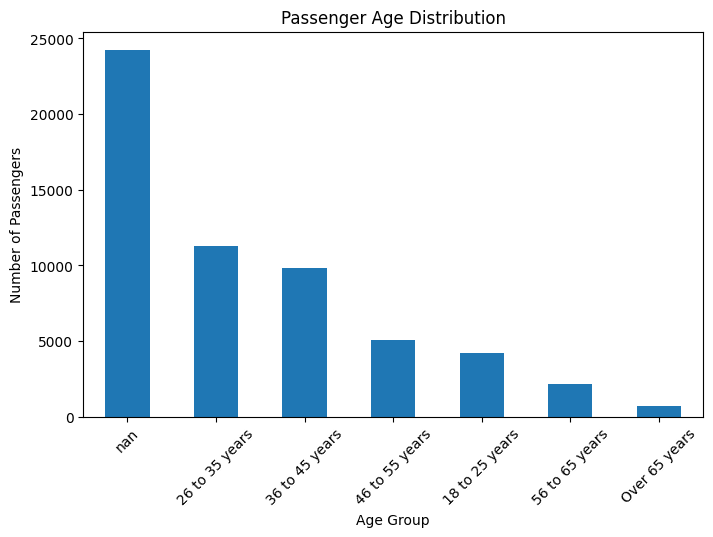

In [18]:
import matplotlib.pyplot as plt

age_counts.plot(kind="bar", figsize=(8,5))
plt.title("Passenger Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.show()

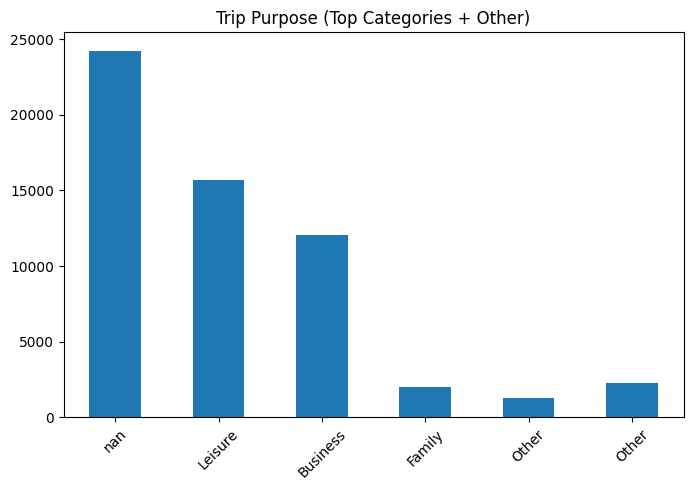

In [22]:
top = trip_purpose.head(5)
other = trip_purpose.iloc[5:].sum()

plot_data = pd.concat([top, pd.Series({"Other": other})])

plot_data.plot(kind="bar", figsize=(8,5))
plt.title("Trip Purpose (Top Categories + Other)")
plt.xticks(rotation=45)
plt.show()

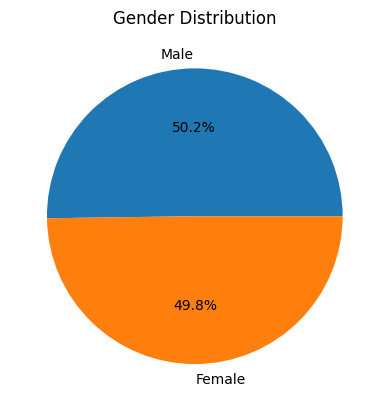

In [26]:
gender_counts = df["gender"].value_counts()

gender_counts.plot(kind="pie", autopct='%1.1f%%')
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

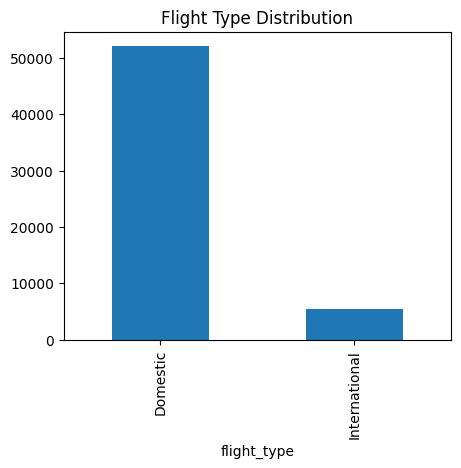

In [27]:
flight_counts = df["flight_type"].value_counts()
flight_counts.plot(kind="bar", figsize=(5,4))
plt.title("Flight Type Distribution")
plt.show()

Which customer segments contribute the most passengers?

Based on what we found:

- Domestic passengers are the dominant segment (~90%).

- Most passengers with known age data are 26–45 years old.

- Leisure and business travelers are the largest travel-purpose groups.

- Gender distribution is relatively balanced.

Moving to the second part:

In [42]:
df.groupby("airport_internet")["liked"].mean()
internet_table = df.groupby("airport_internet")["liked"].mean().reset_index()

internet_table.columns = ["airport_internet", "pct_liked"]
internet_table["pct_liked"] = internet_table["pct_liked"] * 100
internet_table

,airport_internet,pct_liked
0,1.0,13.138686
1,2.0,20.841683
2,3.0,33.104126
3,4.0,48.565710
4,5.0,71.782946


Key insight:
👉 As internet quality increases, satisfaction increases sharply
From:
13% → 72%
That’s almost a 6x increase

“Airport internet quality is a strong driver of passenger satisfaction, showing a clear upward trend across rating levels.”

Interpretation in business terms:

- Poor internet = major dissatisfaction factor

- High-quality internet = strong satisfaction booster

- Likely a differentiator, not just a “nice-to-have”

In [44]:
comfort_table = df.groupby("boarding_lounge_comfort")["liked"].mean().reset_index()

comfort_table.columns = ["boarding_lounge_comfort", "pct_liked"]
comfort_table["pct_liked"] = comfort_table["pct_liked"] * 100
comfort_table

,boarding_lounge_comfort,pct_liked
0,1.0,3.492277
1,2.0,7.026239
2,3.0,23.425809
3,4.0,62.440327
4,5.0,85.512027


Boarding lounge comfort shows a non-linear relationship with passenger satisfaction, with a sharp increase in satisfaction after rating level 3, indicating a critical service threshold effect.

This suggests:

1. Low ratings are catastrophic

If lounge comfort is bad (1–3), satisfaction collapses.

2. Medium improvement has outsized impact

Going from “average” to “good” (3 → 4) is the biggest lever.

3. High-quality lounges strongly drive loyalty

At rating 5, satisfaction reaches 85% → very strong retention driver.

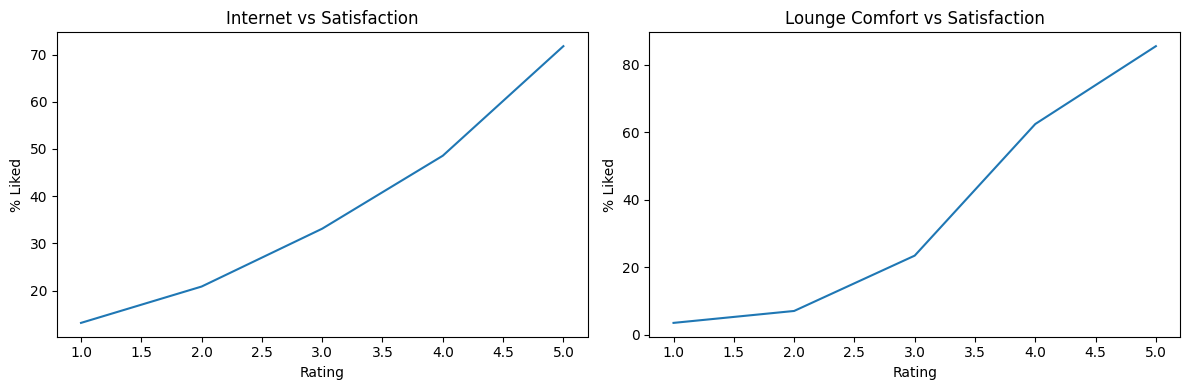

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(internet_table["airport_internet"], internet_table["pct_liked"])
axes[0].set_title("Internet vs Satisfaction")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("% Liked")

axes[1].plot(comfort_table["boarding_lounge_comfort"], comfort_table["pct_liked"])
axes[1].set_title("Lounge Comfort vs Satisfaction")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("% Liked")

plt.tight_layout()
plt.show()

In [40]:
food_table = df.groupby("food_beverage_outlets")["liked"].mean().reset_index()

food_table.columns = ["food_beverage_outlets", "pct_liked"]
food_table["pct_liked"] = food_table["pct_liked"] * 100
food_table

,food_beverage_outlets,pct_liked
0,1.0,10.171569
1,2.0,11.744023
2,3.0,22.174244
3,4.0,51.345415
4,5.0,72.538441


In [46]:
cleanliness_table = df.groupby("overall_airport_cleanliness")["liked"].mean().reset_index()

cleanliness_table.columns = ["overall_airport_cleanliness", "pct_liked"]
cleanliness_table["pct_liked"] = cleanliness_table["pct_liked"] * 100
cleanliness_table

,overall_airport_cleanliness,pct_liked
0,1.0,4.938272
1,2.0,2.724177
2,3.0,8.216893
3,4.0,42.986425
4,5.0,75.263655


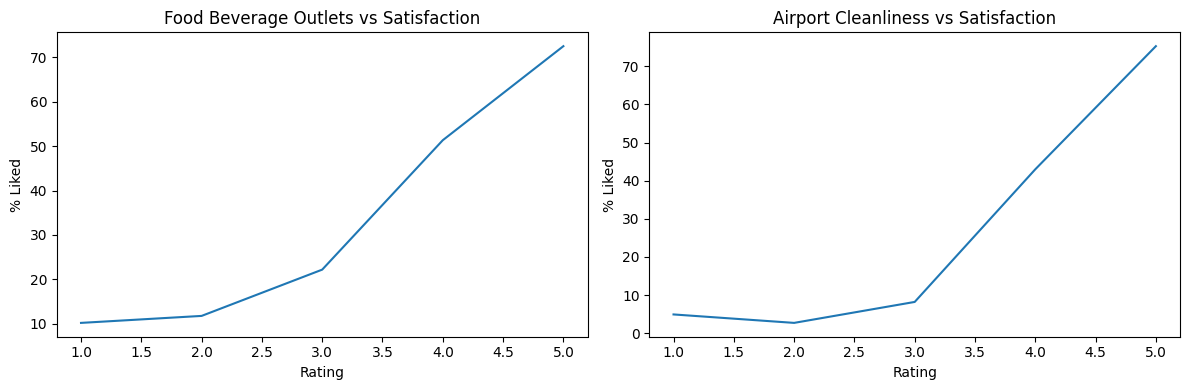

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(food_table["food_beverage_outlets"], food_table["pct_liked"])
axes[0].set_title("Food Beverage Outlets vs Satisfaction")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("% Liked")

axes[1].plot(cleanliness_table["overall_airport_cleanliness"], cleanliness_table["pct_liked"])
axes[1].set_title("Airport Cleanliness vs Satisfaction")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("% Liked")

plt.tight_layout()
plt.show()

1. Weak impact at low-mid range
1 → 3 barely changes (10% → 22%)

 passengers are still mostly dissatisfied even with small improvements

2. Strong jump after level 3
3 → 4: 22% → 51%

 this is the key threshold
 
3. High quality matters a lot
5 reaches 72%

 good food experience strongly supports satisfaction

 Interpretation

--> Food & beverage is a “mid-to-high sensitivity driver”

Not critical when bad (like lounge comfort or cleanliness)
But becomes important once basic service is decent

Business meaning:
Improving from “average” to “good” has the biggest ROI

Food quality is a supporting satisfaction enhancer, not the primary driver

1. Extremely low tolerance for poor cleanliness
Ratings 1–3 → satisfaction is basically near zero

 This is a hard failure zone

2. Massive threshold effect at rating 4
3 → 4 jumps:

8% → 43% (!!)

3. Strong satisfaction only at top level

5 → 75%

Interpretation:

--> Cleanliness is a “critical hygiene factor”

This is NOT optional.

It behaves like:

If bad → passengers are strongly dissatisfied

If good → satisfaction rises sharply

Business meaning:
  Cleanliness is a non-negotiable baseline requirement.
It directly impacts perception of the entire airport.

Which service factors have the strongest impact on satisfaction?

🔴 Critical drivers (HIGHEST impact)

boarding_lounge_comfort
overall_airport_cleanliness

👉 These show:

- extreme low satisfaction when poor
- strong threshold effects
- big jumps at rating 4–5

🟠 Strong supporting drivers
airport_internet

👉 smooth increase, strong linear effect

🟡 Secondary drivers
food_beverage_outlets

👉 matters, but not as catastrophic when poor

Passenger satisfaction is primarily driven by core airport experience factors (cleanliness and lounge comfort), which act as critical thresholds, while digital services and food & beverage act as secondary enhancers that improve satisfaction once baseline experience is acceptable.

In [48]:
df[["arrival_lead_time", "connection_wait_time"]].head()
df[["arrival_lead_time", "connection_wait_time"]].describe()

,arrival_lead_time,connection_wait_time
count,22307.000000,10975.000000
mean,7190.357287,8981.220957
std,2737.401927,2688.524297
min,2700.000000,2700.000000
25%,4500.000000,6300.000000
50%,6300.000000,10800.000000
75%,9900.000000,10800.000000
max,10800.000000,10800.000000


In [56]:
bins = [0, 3600, 7200, 10800]
labels = ["<1h", "1-2h", "2-3h"]

df["connection_group"] = pd.cut(
    df["connection_wait_time"],
    bins=bins,
    labels=labels
)

connection_results = df.groupby(
    "connection_group",
    observed=True
)["liked"].mean()

connection_results

connection_group
<1h     0.428066
1-2h    0.433933
2-3h    0.419091
Name: liked, dtype: float64

In [51]:
bins = [0, 5400, 9000, 10801]
labels = ["<90 min", "90-150 min", ">150 min"]

df["arrival_group"] = pd.cut(
    df["arrival_lead_time"],
    bins=bins,
    labels=labels
)

df.groupby(
    "arrival_group",
    observed=True
)["liked"].mean()

arrival_group
<90 min       0.504161
90-150 min    0.535195
>150 min      0.522230
Name: liked, dtype: float64

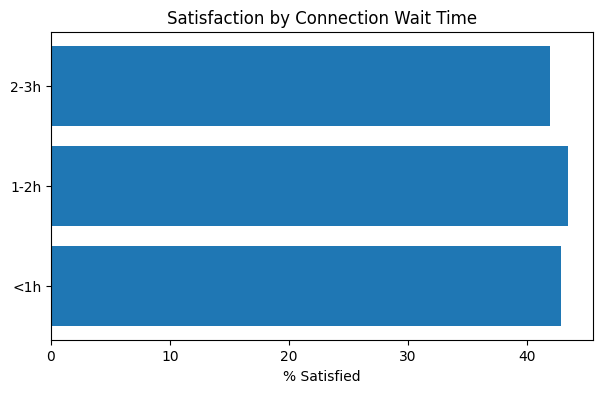

In [58]:
connection_pct = connection_results * 100

plt.figure(figsize=(7,4))
plt.barh(connection_pct.index, connection_pct.values)

plt.xlabel("% Satisfied")
plt.title("Satisfaction by Connection Wait Time")
plt.show()

Connection waiting time does not appear to have a meaningful impact on overall passenger satisfaction within the observed range (45 minutes to 3 hours).

Passenger satisfaction remains relatively stable regardless of how early passengers arrive at the airport.

Passenger satisfaction is driven much more by service quality and comfort factors than by arrival lead times or connection waiting times.